# Identificação NARX v3 (Free-Run Val + ResNet) (Melhores Práticas)
Neste notebook, aplicamos as melhorias discutidas para o modelo NARX:
1. Uso de múltiplos datasets de treino (iguais ao `node_v4.py`).
2. Redução das ordens `ny` e `nu` para capturar a dinâmica fundamental sem overfitting de ruído.
3. Arquitetura de rede mais compacta.
4. Concatenação adequada dos datasets.
5. Validação guiada pelo erro de Free-Run.
6. Bypass Linear na Arquitetura (ResNet).


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

# Seed para reprodutibilidade
rseed = 42
np.random.seed(rseed)
torch.manual_seed(rseed)
np.set_printoptions(precision=3)

device = torch.device('cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Funções Auxiliares


In [25]:
def matReg(y, u, ny, nu):
    p = max(ny, nu) + 1
    (N, ) = y.shape
    (Nu, ) = u.shape

    if N != Nu:
        print('Dimensões inconsistentes')
        return (-1,-1)

    target = y[p-1:N]
    Phi = np.zeros((N-p+1, ny+nu))
    
    for i in range(ny):
        Phi[:, i] = y[p-i-2 : N-i-1]
    for i in range(nu):
        Phi[:, i+ny] = u[p-i-2 : N-i-1]

    return (target, Phi)

def freeRun(model, y, u, ny, nu, device):
    p = max(ny, nu) + 1
    (N, ) = y.shape

    yhat = np.zeros(N)
    yhat[:p-1] = y[:p-1] 

    for k in range(p, N+1):
        auxY = np.concatenate((yhat[(k-p):(k-1)], (0,)), axis=0)
        auxU = np.concatenate((u[(k-p):(k-1)], (0,)), axis=0)

        _, fr_input = matReg(auxY, auxU, ny, nu)
        
        tensor_input = torch.tensor(fr_input, dtype=torch.float32).to(device)
        yhat[k-1] = model.predict(tensor_input).item()
        
    return yhat[-(N-p+1):]


## 2. Carregamento e Preparação dos Múltiplos Datasets
Usamos os mesmos conjuntos de Treino e Validação do `node_v4.py`.
Também aplicamos o corte inicial/final para tirar os ruídos e a decimação por 2.


In [26]:
from scipy.signal import decimate

def carregar_experimento(url, decimacao=2, start_idx=1300, end_idx=-1600):
    df = pd.read_csv(url)
    
    if 'u_pct' in df.columns:
        u_full = df['u_pct'].values
    else:
        u_full = df['motor_percent'].values
        
    y_full = df['angulo_deg'].values
    
    # Para y (sensor) - filtro anti-aliasing
    y_raw = decimate(y_full, decimacao, ftype='iir', zero_phase=True)
    # Para u (controle) - subsampling direto preserva degraus
    u_raw = u_full[::decimacao]
    
    u = u_raw[start_idx:end_idx]
    y = y_raw[start_idx:end_idx]
    return u, y

BASE2 = "https://raw.githubusercontent.com/FelipeEduardoMarcondes/SYSTEM-IDENTIFICATION-AERO/main/experimentos/"

train_files = [
    "aprbs-1_0819_18-48.csv",
    "aprbs-2_0819_18-51.csv",
    "aprbs-neg-1_0819_18-54.csv",
    "multi-seno-1_0819_19-23.csv",
    "multi-seno-2_0819_18-59.csv",
    "multi-seno-2_0819_19-11.csv",
    "multi-seno-3_0819_19-19.csv",
    "seq-degraus-aprbs-2_0819_19-16.csv",
    "swept-sine-1_0819_19-02.csv",
        "RODADA-3/multi-seno-1_0807_16-57.csv",
        "RODADA-3/multi-seno-2_0807_17-13.csv",
        "RODADA-3/seq-degraus-1_0807_16-38.csv",
        "RODADA-3/seq-degraus-aprbs-2_0807_17-23.csv",
        "RODADA-3/seq-dragus-aprbs_0807_16-50.csv"
]

val_files = [
    "RODADA-2/chirp-1_0804_19-19.csv",
    "RODADA-2/multi-seno-2_0804_19-28.csv",
    "RODADA-2/seq-degraus-1_0804_19-09.csv",
    "RODADA-2/multi-seno-1_0804_19-06.csv",
    "RODADA-2/seq-degraus-2_0804_19-38.csv",
    "RODADA-2/multi-seno-3_0804_19-44.csv",
    "RODADA-2/seq-degraus-1_0804_19-12.csv"
]

scaler_u = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))
scaler_u.fit(np.array([[0], [100]]))
scaler_y.fit(np.array([[-180], [180]]))

print("Carregando e processando conjuntos de TREINO...")
u_train_list, y_train_list = [], []
for f in train_files:
    u, y = carregar_experimento(BASE2 + f, decimacao=2, start_idx=700, end_idx=-900)
    u_norm = scaler_u.transform(u.reshape(-1, 1)).flatten()
    y_norm = scaler_y.transform(y.reshape(-1, 1)).flatten()
    u_train_list.append(u_norm)
    y_train_list.append(y_norm)

print("Carregando e processando conjuntos de TESTE/VALIDAÇÃO...")
u_val_list, y_val_list = [], []
for f in val_files:
    u, y = carregar_experimento(BASE2 + f, decimacao=2, start_idx=700, end_idx=-900)
    u_norm = scaler_u.transform(u.reshape(-1, 1)).flatten()
    y_norm = scaler_y.transform(y.reshape(-1, 1)).flatten()
    u_val_list.append(u_norm)
    y_val_list.append(y_norm)


Carregando e processando conjuntos de TREINO...
Carregando e processando conjuntos de TESTE/VALIDAÇÃO...


## Visualização dos Conjuntos de Treino
Abaixo estão os gráficos da variável de saída (ângulo) para cada um dos 9 conjuntos de treinamento.


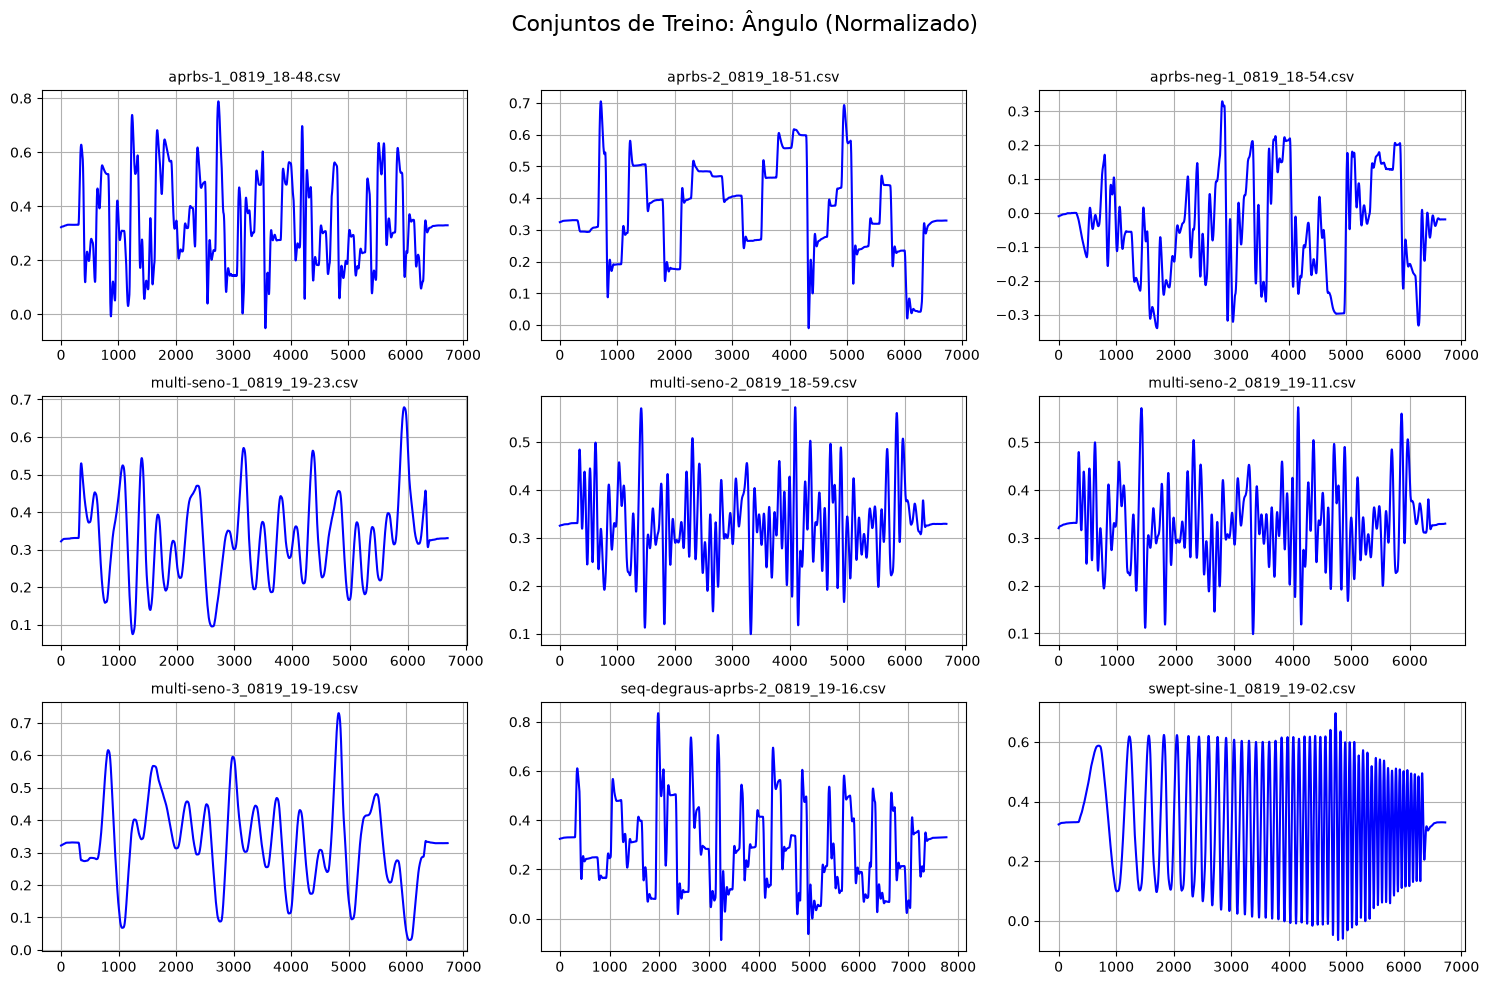

In [27]:
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Conjuntos de Treino: Ângulo (Normalizado)', fontsize=16)

for i, ax in enumerate(axs.flatten()):
    if i < len(y_train_list):
        ax.plot(y_train_list[i], color='blue')
        ax.set_title(train_files[i], fontsize=10)
        ax.grid(True)
    else:
        ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


## 3. Matrizes de Regressão e Tensores
Geramos a matriz regressora separadamente para CADA dataset e depois as concatenamos.
Isto evita que o final de um experimento seja usado para prever o início do outro experimento.


In [28]:
# Reduzindo a ordem! 100 era overfitting demais.
ny = 30
nu = 50

Phie_all, Ye_all = [], []
for y_n, u_n in zip(y_train_list, u_train_list):
    (Y, Phi) = matReg(y_n, u_n, ny, nu)
    Ye_all.append(Y)
    Phie_all.append(Phi)

# Concatena todos os dados de treino
Ye_concat = np.concatenate(Ye_all, axis=0)
Phie_concat = np.concatenate(Phie_all, axis=0)

# O mesmo para validação (vamos apenas concatenar para fins de cálculo de loss rápido)
Yt_all, Phit_all = [], []
for y_n, u_n in zip(y_val_list, u_val_list):
    (Y, Phi) = matReg(y_n, u_n, ny, nu)
    Yt_all.append(Y)
    Phit_all.append(Phi)

Yt_concat = np.concatenate(Yt_all, axis=0)
Phit_concat = np.concatenate(Phit_all, axis=0)

Phie_t = torch.tensor(Phie_concat, dtype=torch.float32).to(device)
Ye_t   = torch.tensor(Ye_concat, dtype=torch.float32).view(-1, 1).to(device)

Phit_t = torch.tensor(Phit_concat, dtype=torch.float32).to(device)
Yt_t   = torch.tensor(Yt_concat, dtype=torch.float32).view(-1, 1).to(device)

# Noise Injection para ajudar no Free-Run
ruido = torch.randn_like(Phie_t[:, :ny]) * 0.05 
Phie_t[:, :ny] += ruido

dataset = TensorDataset(Phie_t, Ye_t)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)


## 4. Arquitetura da Rede e Treinamento


In [29]:
class NARXModel(nn.Module):
    def __init__(self, ny, nu, hidden_dim1=256, hidden_dim2=128, dropout=0.1):
        super().__init__()
        self.linear_bypass = nn.Linear(ny + nu, 1)
        self.net = nn.Sequential(
            nn.Linear(ny + nu, hidden_dim1),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, 1)
        )
    
    def forward(self, x):
        return self.linear_bypass(x) + self.net(x)
    
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            return self.forward(x)


In [30]:
model = NARXModel(ny, nu, 128, 64).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

epochs = 1000
best_val_loss = float('inf')
patience_counter = 0
patience_limit = 150  # épocas sem melhora

for epoch in range(epochs):
    # Ruído decresce ao longo do treino: começa alto, termina baixo
    noise_std = 0.1 * (1 - epoch / epochs)  # de 0.1 a 0.0
    
    model.train()
    epoch_loss = 0.0
    for inputs, targets in dataloader:
        noisy_inputs = inputs.clone()
        noisy_inputs[:, :ny] += torch.randn_like(noisy_inputs[:, :ny]) * noise_std
        
        optimizer.zero_grad()
        outputs = model(noisy_inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    epoch_loss /= len(dataloader)
    
    # Validação via Free-Run
    # Vamos avaliar o Free-Run no primeiro dataset de validação para guiar o Early Stopping
    model.eval()
    if (epoch + 1) % 5 == 0 or epoch == 0:
        y_val_fr = y_val_list[0]
        u_val_fr = u_val_list[0]
        y_test_pred_fr = freeRun(model, y_val_fr, u_val_fr, ny, nu, device)
        
        p = max(ny, nu) + 1
        y_real_eval = y_val_fr[p-1:]
        
        # MSE do Free-Run
        val_loss = np.mean((y_real_eval - y_test_pred_fr)**2)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_narx.pth')
            patience_counter = 0
        else:
            patience_counter += 5 # Incrementa 5 pois checamos a cada 5 épocas
            
        print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss (OSA): {epoch_loss:.5f} | Val Loss (Free-Run): {val_loss:.5f}')
        
        if patience_counter >= patience_limit:
            print(f"Early stopping na epoch {epoch+1}")
            break



Epoch   1/1000 | Train Loss (OSA): 0.00310 | Val Loss (Free-Run): 0.01013
Epoch   5/1000 | Train Loss (OSA): 0.00118 | Val Loss (Free-Run): 0.00818
Epoch  10/1000 | Train Loss (OSA): 0.00116 | Val Loss (Free-Run): 0.00767
Epoch  15/1000 | Train Loss (OSA): 0.00117 | Val Loss (Free-Run): 0.00628
Epoch  20/1000 | Train Loss (OSA): 0.00115 | Val Loss (Free-Run): 0.00857
Epoch  25/1000 | Train Loss (OSA): 0.00115 | Val Loss (Free-Run): 0.00653
Epoch  30/1000 | Train Loss (OSA): 0.00114 | Val Loss (Free-Run): 0.00578
Epoch  35/1000 | Train Loss (OSA): 0.00114 | Val Loss (Free-Run): 0.01069
Epoch  40/1000 | Train Loss (OSA): 0.00115 | Val Loss (Free-Run): 0.00795
Epoch  45/1000 | Train Loss (OSA): 0.00114 | Val Loss (Free-Run): 0.00876
Epoch  50/1000 | Train Loss (OSA): 0.00111 | Val Loss (Free-Run): 0.00740
Epoch  55/1000 | Train Loss (OSA): 0.00111 | Val Loss (Free-Run): 0.00609
Epoch  60/1000 | Train Loss (OSA): 0.00111 | Val Loss (Free-Run): 0.01134
Epoch  65/1000 | Train Loss (OSA): 0.0

## 5. Avaliação Free-Run no conjunto de Validação


--- FREE-RUN NOS DATASETS DE TESTE ---
Dataset: RODADA-2/chirp-1_0804_19-19.csv
  R2: 0.3448 | RMSE: 15.08 graus


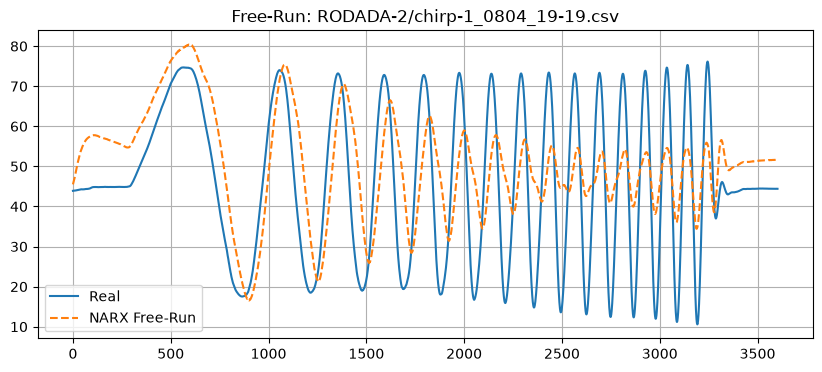

Dataset: RODADA-2/multi-seno-2_0804_19-28.csv
  R2: 0.4125 | RMSE: 17.01 graus


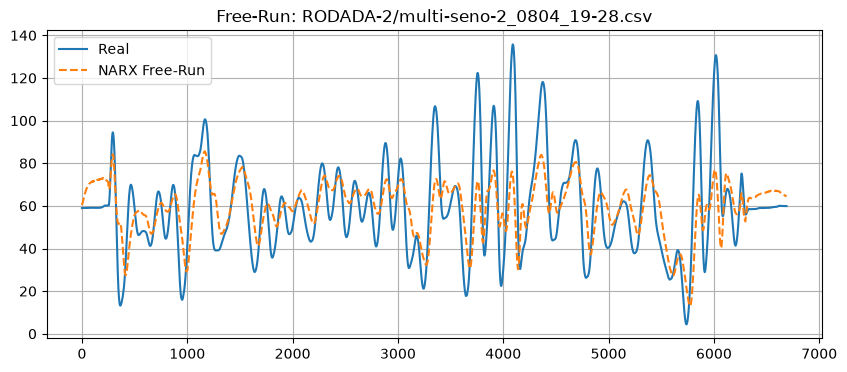

Dataset: RODADA-2/seq-degraus-1_0804_19-09.csv
  R2: 0.6312 | RMSE: 13.19 graus


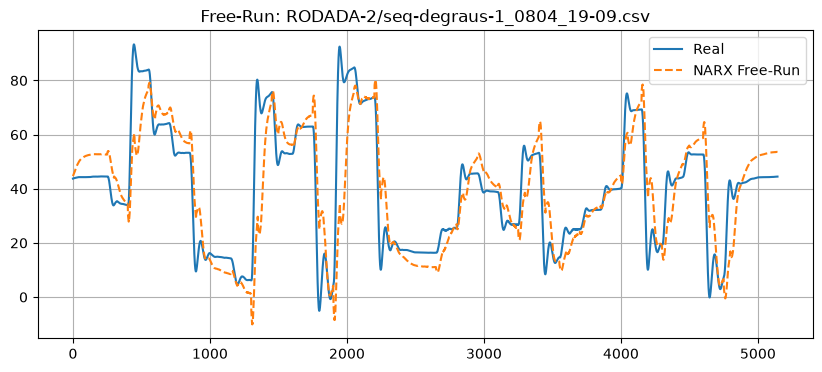

Dataset: RODADA-2/multi-seno-1_0804_19-06.csv
  R2: 0.5220 | RMSE: 12.48 graus


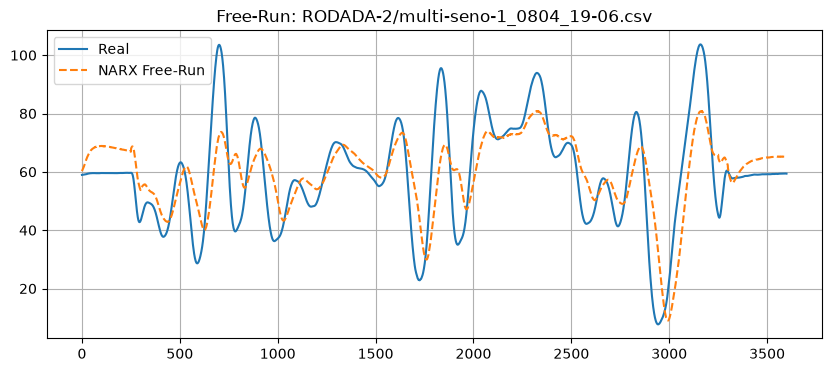

Dataset: RODADA-2/seq-degraus-2_0804_19-38.csv
  R2: 0.6265 | RMSE: 15.91 graus


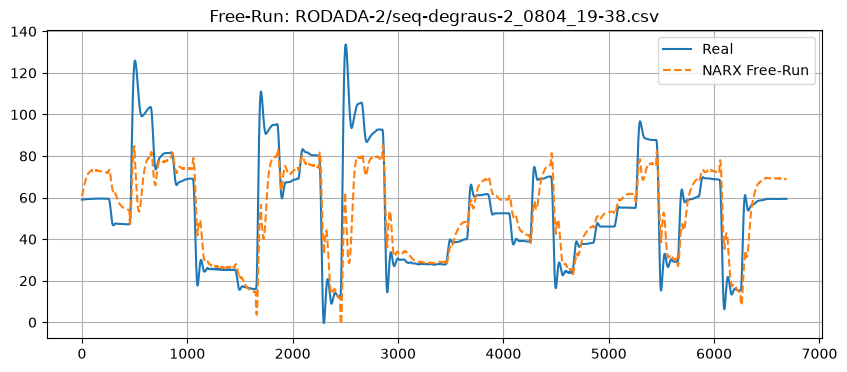

Dataset: RODADA-2/multi-seno-3_0804_19-44.csv
  R2: 0.7113 | RMSE: 12.79 graus


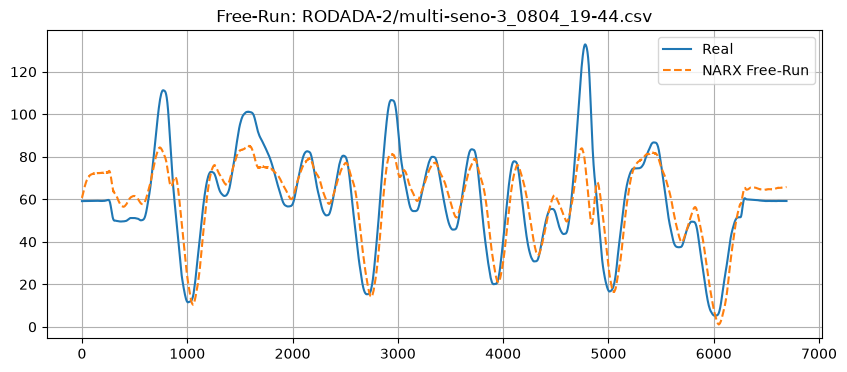

Dataset: RODADA-2/seq-degraus-1_0804_19-12.csv
  R2: 0.6321 | RMSE: 13.16 graus


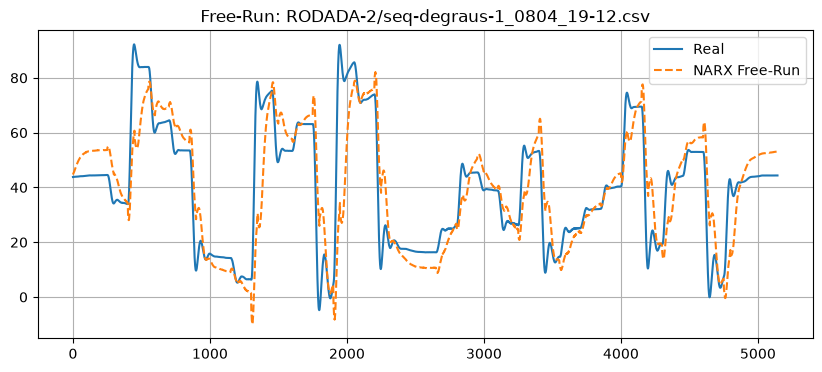

In [31]:
print("--- FREE-RUN NOS DATASETS DE TESTE ---")
rmse_list = []

for i, (y_n, u_n, file_name) in enumerate(zip(y_val_list, u_val_list, val_files)):
    y_test_pred0  = freeRun(model, y_n, u_n, ny, nu, device)
    
    y_real_original = scaler_y.inverse_transform(y_n.reshape(-1, 1)).flatten()
    y_pred_original = scaler_y.inverse_transform(y_test_pred0.reshape(-1, 1)).flatten()
    
    p = max(ny, nu) + 1
    # y_pred_original já vem sem as condições iniciais (tamanho N - p + 1)
    # Precisamos pegar exatamente a mesma janela do y_real
    y_real_eval = y_real_original[p-1:]
    y_pred_eval = y_pred_original
    
    r2 = r2_score(y_real_eval, y_pred_eval)
    rmse = np.sqrt(np.mean((y_real_eval - y_pred_eval)**2))
    
    print(f"Dataset: {file_name}")
    print(f"  R2: {r2:.4f} | RMSE: {rmse:.2f} graus")
    
    plt.figure(figsize=(10,4))
    plt.plot(y_real_eval, label='Real')
    plt.plot(y_pred_eval, label='NARX Free-Run', linestyle='dashed')
    plt.title(f'Free-Run: {file_name}')
    plt.legend()
    plt.grid()
    plt.show()
